In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

Using Colab cache for faster access to the 'plantdisease' dataset.


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

Enfermedades detectadas en el directorio:
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot'] ... entre otras.
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

¡Perfecto! Se detectaron: 15 clases reales.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,455 (240.06 KB)

 Trainable params: 61,455 (240.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 74s 89ms/step - accuracy: 0.2639 - loss: 2.2530 - val_accuracy: 0.3918 - val_loss: 1.8868
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.4844 - loss: 1.6019 - val_accuracy: 0.5493 - val_loss: 1.4177
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6004 - loss: 1.2366 - val_accuracy: 0.6419 - val_loss: 1.0726
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6649 - loss: 1.0130 - val_accuracy: 0.6806 - val_loss: 0.9655
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6994 - loss: 0.8881 - val_accuracy: 0.7136 - val_loss: 0.8336
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7373 - loss: 0.7787 - val_accuracy: 0.7625 - val_loss: 0.7043
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7603 - loss: 0.6987 - val_accuracy: 0.7764 - val_loss: 0.6708
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7818 - loss: 0.6405 - val_acc

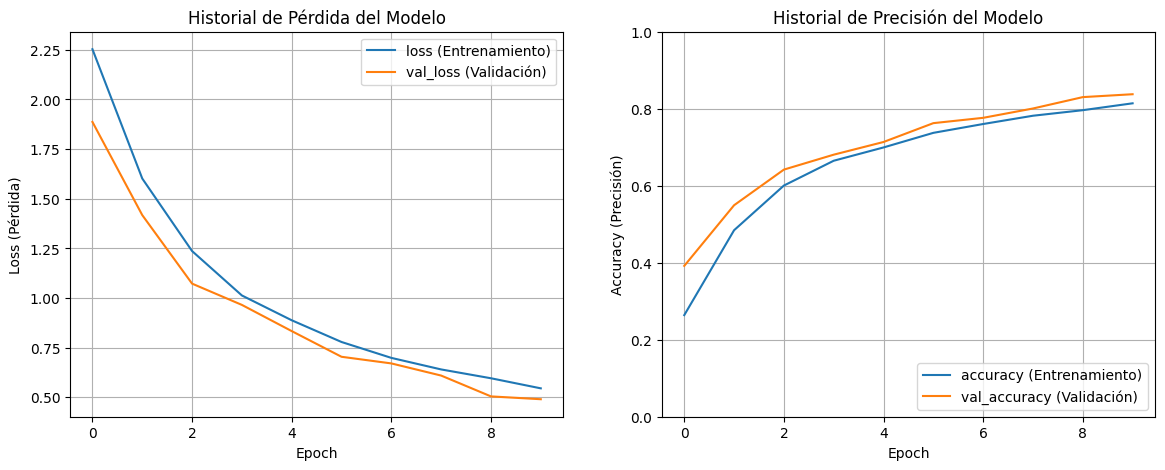

In [4]:
data_dir = os.path.join(path, 'PlantVillage')

print("Enfermedades detectadas en el directorio:")
print(os.listdir(data_dir)[:5], "... entre otras.")

IMG_SIZE = (128, 128)
BATCH_SIZE = 64
CHANNELS = 3

# Entrenamiento
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Validación
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extracción de metadatos
class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)
print(f"\nSe detectaron: {NUM_CLASSES} clases.")

# Pipeline de rendimiento con tf.data
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# CNN
model = models.Sequential([
    # Escalado de píxeles integrado en el modelo
    layers.Rescaling(1./255, input_shape=IMG_SIZE + (CHANNELS,)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # REEMPLAZO DE FLATTEN: GlobalAveragePooling2D reduce radicalmente los parámetros
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),

    # Capa de salida para las 15 clases
    layers.Dense(NUM_CLASSES)
])

In [ ]:
# Modelo
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

# Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Pérdida
ax1.plot(history.history['loss'], label='loss (Entrenamiento)')
ax1.plot(history.history['val_loss'], label='val_loss (Validación)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Pérdida)')
ax1.grid(True)
ax1.legend(loc='upper right')
ax1.set_title('Historial de Pérdida del Modelo')

# Gráfica de Precisión
ax2.plot(history.history['accuracy'], label='accuracy (Entrenamiento)')
ax2.plot(history.history['val_accuracy'], label='val_accuracy (Validación)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (Precisión)')
ax2.set_ylim([0, 1])
ax2.grid(True)
ax2.legend(loc='lower right')
ax2.set_title('Historial de Precisión del Modelo')

plt.show()

In [5]:
# Transfer Learning
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,    # Quitamos la capa de clasificación de ImageNet
    weights='imagenet'    # Cargamos los pesos preentrenados
)

# Congelamos la base para hacer TL
base_model.trainable = False

# Modelo usando la API Funcional de Keras para mayor control
inputs = tf.keras.Input(shape=(128, 128, 3))

# MobileNetV2 requiere que las entradas estén normalizadas estrictamente entre -1 y 1
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Evita sobreajuste en la capa final
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)

# Compilamos el modelo de Transfer Learning
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

# Entrenamos
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 53s 134ms/step - accuracy: 0.6983 - loss: 0.9661 - val_accuracy: 0.8626 - val_loss: 0.4553
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8622 - loss: 0.4359 - val_accuracy: 0.8919 - val_loss: 0.3499
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8903 - loss: 0.3450 - val_accuracy: 0.9050 - val_loss: 0.3001
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9076 - loss: 0.2954 - val_accuracy: 0.9137 - val_loss: 0.2741
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9144 - loss: 0.2679 - val_accuracy: 0.9186 - val_loss: 0.2599
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9248 - loss: 0.2412 - val_accuracy: 0.9181 - val_loss: 0.2504
Epoch 7/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9290 - loss: 0.2258 - val_accuracy: 0.9188 - val_loss: 0.2395
Epoch 8/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9298 - loss: 0.2157 - val_accuracy: 

In [6]:
# Fine-Tuning
base_model.trainable = True

# Volvemos a congelar las primeras capas y dejamos libres solo las últimas (ej. las últimas 20)
# Esto evita que el modelo "olvide" cómo detectar formas básicas (líneas, colores)
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# RECOMPILAR ES OBLIGATORIO tras cambiar el estado de 'trainable'
# Usamos una tasa de aprendizaje 10 veces menor (1e-4 o 1e-5) para no destruir los pesos
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos un par de épocas extra para el ajuste fino
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.8877 - loss: 0.3752 - val_accuracy: 0.7679 - val_loss: 0.8296
Epoch 2/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9784 - loss: 0.0695 - val_accuracy: 0.8461 - val_loss: 0.5293
Epoch 3/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9930 - loss: 0.0276 - val_accuracy: 0.9089 - val_loss: 0.2962
Epoch 4/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9974 - loss: 0.0130 - val_accuracy: 0.9188 - val_loss: 0.2544
Epoch 5/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9999 - loss: 0.0060 - val_accuracy: 0.9368 - val_loss: 0.1905
